<a href="https://colab.research.google.com/github/MeenakshiGanesan/bdml-lab/blob/main/build5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== K-MEANS CLUSTERING ===


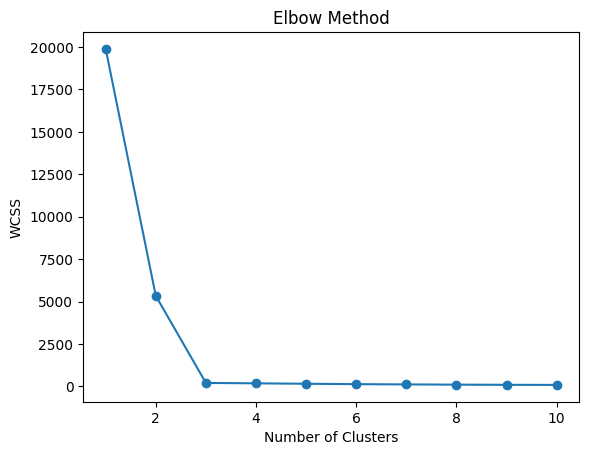

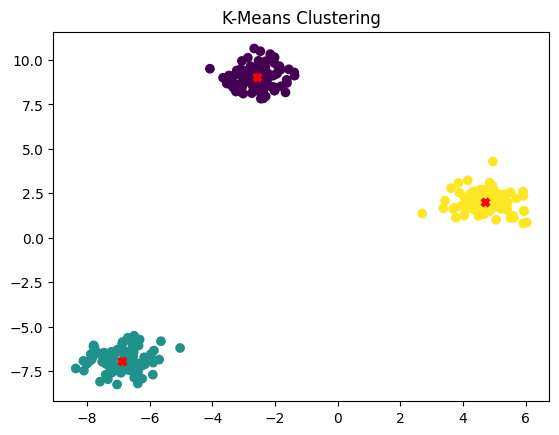

Silhouette Score: 0.9083834454815235

=== PCA DIMENSIONALITY REDUCTION ===
Explained Variance Ratio: [0.57208431 0.33622342]


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

print("=== K-MEANS CLUSTERING ===")
X, y = make_blobs(n_samples=300, centers=3, cluster_std=0.60, random_state=42)

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X)
plt.scatter(X[:,0], X[:,1], c=clusters, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], c='red', marker='X')
plt.title("K-Means Clustering")
plt.show()

print("Silhouette Score:", silhouette_score(X, clusters))

print("\n=== PCA DIMENSIONALITY REDUCTION ===")
X_pca, y_pca = make_blobs(n_samples=500, n_features=4, centers=4, random_state=25)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

pca = PCA(n_components=2)
pc = pca.fit_transform(X_scaled)
print("Explained Variance Ratio:", pca.explained_variance_ratio_)




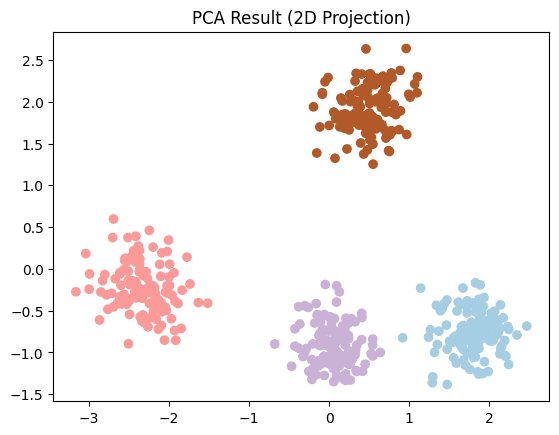

In [3]:
plt.scatter(pc[:,0], pc[:,1], c=y_pca, cmap='Paired')
plt.title("PCA Result (2D Projection)")
plt.show()



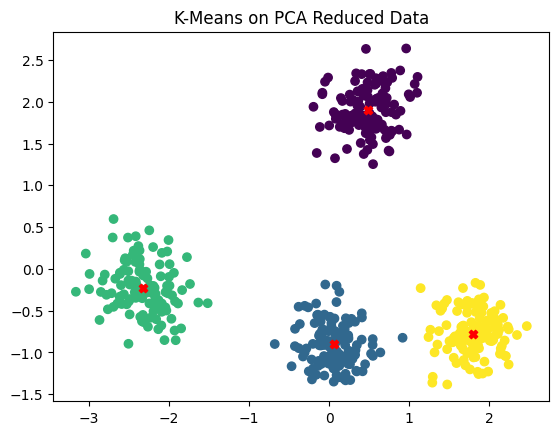

Silhouette Score on PCA Data: 0.7764383951477865


In [4]:
kmeans_pca = KMeans(n_clusters=4, random_state=42)
pca_clusters = kmeans_pca.fit_predict(pc)
plt.scatter(pc[:,0], pc[:,1], c=pca_clusters, cmap='viridis')
plt.scatter(kmeans_pca.cluster_centers_[:,0], kmeans_pca.cluster_centers_[:,1], c='red', marker='X')
plt.title("K-Means on PCA Reduced Data")
plt.show()

print("Silhouette Score on PCA Data:", silhouette_score(pc, pca_clusters))